In [100]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ( 
    confusion_matrix, 
    accuracy_score,
    precision_recall_fscore_support,
    roc_curve,
    auc,
    precision_recall_curve, 
    average_precision_score
)
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from wordcloud import WordCloud
import warnings
import textwrap
warnings.filterwarnings('ignore')


### Loading Cleaned Data 

In [83]:
# Loading preprocessed book data
df = pd.read_csv('../data/processed/cleaned_books_balanced.csv')

# Features and labels
df['combined_text'] = df['title'] + ' ' + df['title'] + ' ' + df['description']
X_text = df['combined_text']  # text descriptions
y = df['genre_label']       # encoded genre labels

print(f"Data loaded. Number of samples: {len(df)}")
print("Example descriptions:\n", X_text.head(3))


Data loaded. Number of samples: 9848
Example descriptions:
 0    Don't Breathe a Word Don't Breathe a Word On a...
1    Elements of Chemistry: Capture Elements of Che...
2    Asking For Trouble Asking For Trouble Seduced ...
Name: combined_text, dtype: object


### Train/Test Data Split

In [84]:
# Spliting data into training and testing sets
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train_text)}, Testing samples: {len(X_test_text)}")


Training samples: 7878, Testing samples: 1970


### TF-IDF Vectorization

In [85]:
# Converting text descriptions into numeric features
vectorizer = TfidfVectorizer(
    max_features=15000,           # Increased features
    ngram_range=(1, 3),           # Unigrams, bigrams, and trigrams
    min_df=3,                     # Must appear in at least 3 documents
    max_df=0.85,                  # Ignoring if in more than 85% of docs
    sublinear_tf=True,            # Using log scaling for term frequency
    strip_accents='unicode',      # Handling accented characters
    lowercase=True,
    stop_words='english'          # Removing common English stop words
)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print("TF-IDF feature matrix shape:", X_train.shape)


TF-IDF feature matrix shape: (7878, 15000)


### Training Logistic Regression Model

In [96]:
# Initializing Logistic Regression model
lr_model = LogisticRegression(
    max_iter=1000,             # Increased iterations
    random_state=42,
    class_weight='balanced',   # Handling class imbalance
    C=1.0,                     # Regularization strength
    solver='saga'              # Supports both L1 and L2
)

# Training model
lr_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")
joblib.dump(lr_model, "../models/lr_genre_model.pkl")


Logistic Regression model trained successfully!


['../models/lr_genre_model.pkl']

### Model Evaluation

In [87]:
 #Setting  style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

# Genre names 
GENRE_NAMES = [
    'Fiction',
    'Mystery', 
    'Romance',
    'Science Fiction',
    'Fantasy',
    'Horror',
    'Biography',
    'Self-Help'
]

In [88]:
# Getting predictions on test set
y_pred = lr_model.predict(X_test)

# Getting prediction probabilities for each class
y_pred_proba = lr_model.predict_proba(X_test)

# Calculating metrics
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred)

print("   Predictions Generated:")
print(f"   Test samples: {len(y_test):,}")
print(f"   Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   Average Precision: {precision.mean():.4f}")
print(f"   Average Recall: {recall.mean():.4f}")
print(f"   Average F1-Score: {f1.mean():.4f}")

   Predictions Generated:
   Test samples: 1,970
   Overall Accuracy: 0.6310 (63.10%)
   Average Precision: 0.6319
   Average Recall: 0.6310
   Average F1-Score: 0.6291


### Confusion Matrix Visualization

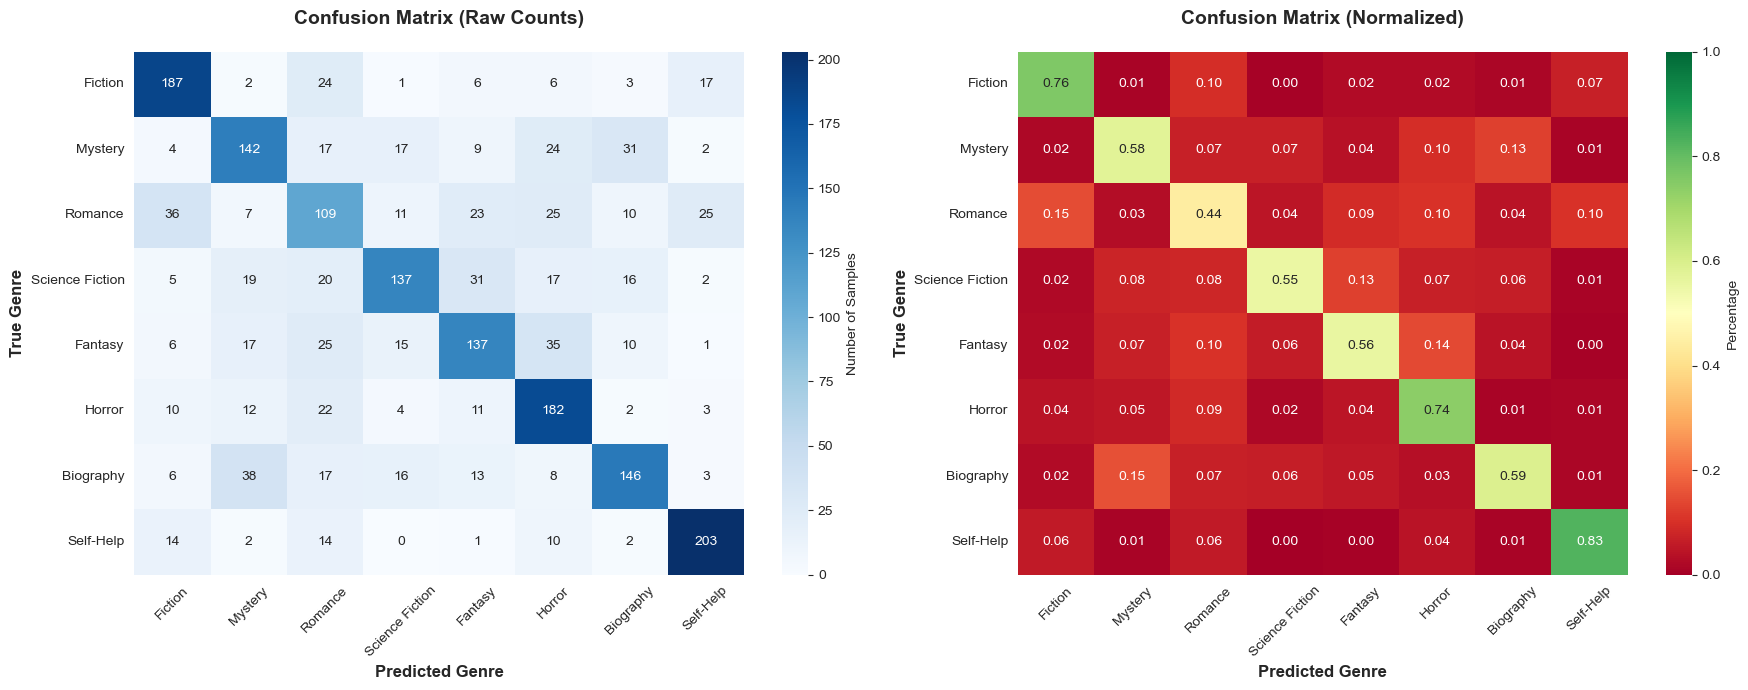


MOST CONFUSED GENRE PAIRS

Top 10 Misclassification Pairs:
     True Genre Predicted As  Count Percentage
      Biography      Mystery     38      15.4%
        Romance      Fiction     36      14.6%
        Fantasy       Horror     35      14.2%
Science Fiction      Fantasy     31      12.6%
        Mystery    Biography     31      12.6%
        Fantasy      Romance     25      10.2%
        Romance    Self-Help     25      10.2%
        Romance       Horror     25      10.2%
        Mystery       Horror     24       9.8%
        Fiction      Romance     24       9.8%


In [89]:
# Calculating confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Creating figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=GENRE_NAMES, yticklabels=GENRE_NAMES,
            cbar_kws={'label': 'Number of Samples'}, ax=axes[0])
axes[0].set_title('Confusion Matrix (Raw Counts)', fontsize=14, fontweight='bold', pad=20)
axes[0].set_xlabel('Predicted Genre', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Genre', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Plot 2: Normalized (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='RdYlGn', 
            xticklabels=GENRE_NAMES, yticklabels=GENRE_NAMES,
            vmin=0, vmax=1, cbar_kws={'label': 'Percentage'}, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold', pad=20)
axes[1].set_xlabel('Predicted Genre', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Genre', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

# Analyzing most confused pairs
print("\n" + "="*80)
print("MOST CONFUSED GENRE PAIRS")
print("="*80)

confused_pairs = []
for i in range(len(GENRE_NAMES)):
    for j in range(len(GENRE_NAMES)):
        if i != j and cm[i, j] > 0:
            confused_pairs.append({
                'True Genre': GENRE_NAMES[i],
                'Predicted As': GENRE_NAMES[j],
                'Count': cm[i, j],
                'Percentage': f"{cm_normalized[i, j]*100:.1f}%"
            })

confused_df = pd.DataFrame(confused_pairs).sort_values('Count', ascending=False)
print("\nTop 10 Misclassification Pairs:")
print(confused_df.head(10).to_string(index=False))

### Per-Class Performance Metrics

PER-CLASS PERFORMANCE METRICS
          Genre  Precision   Recall  F1-Score  Support
        Fiction   0.697761 0.760163  0.727626      246
        Mystery   0.594142 0.577236  0.585567      246
        Romance   0.439516 0.443089  0.441296      246
Science Fiction   0.681592 0.554656  0.611607      247
        Fantasy   0.593074 0.556911  0.574423      246
         Horror   0.592834 0.739837  0.658228      246
      Biography   0.663636 0.591093  0.625268      247
      Self-Help   0.792969 0.825203  0.808765      246


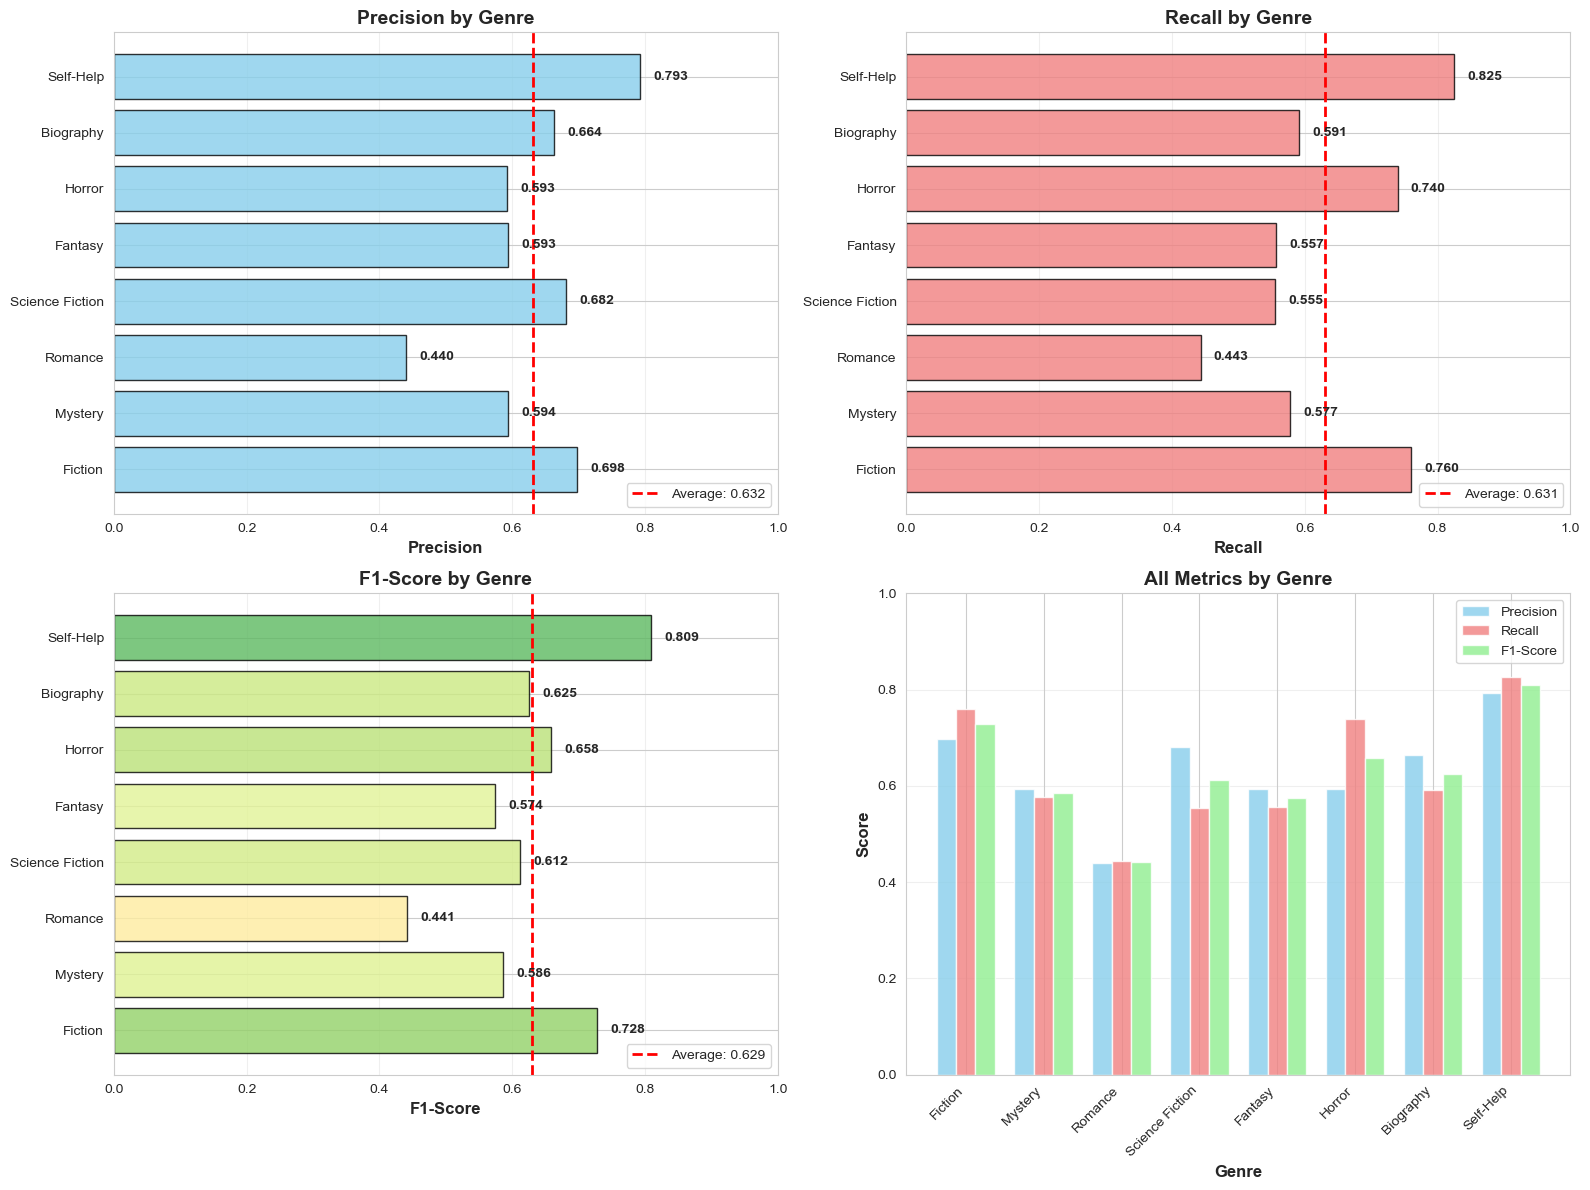

In [90]:
# Genre names 
GENRE_NAMES = [
    'Fiction',
    'Mystery', 
    'Romance',
    'Science Fiction',
    'Fantasy',
    'Horror',
    'Biography',
    'Self-Help'
]

# Creating performance dataframe
performance_df = pd.DataFrame({
    'Genre': GENRE_NAMES,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print("="*80)
print("PER-CLASS PERFORMANCE METRICS")
print("="*80)
print(performance_df.to_string(index=False))

# Visualizing metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Precision by Genre
axes[0, 0].barh(GENRE_NAMES, precision, color='skyblue', alpha=0.8, edgecolor='black')
axes[0, 0].axvline(x=precision.mean(), color='red', linestyle='--', linewidth=2, 
                    label=f'Average: {precision.mean():.3f}')
axes[0, 0].set_xlabel('Precision', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Precision by Genre', fontsize=14, fontweight='bold')
axes[0, 0].set_xlim([0, 1])
axes[0, 0].legend()
axes[0, 0].grid(axis='x', alpha=0.3)

# Adding value labels
for i, v in enumerate(precision):
    axes[0, 0].text(v + 0.02, i, f'{v:.3f}', va='center', fontweight='bold')

# 2. Recall by Genre
axes[0, 1].barh(GENRE_NAMES, recall, color='lightcoral', alpha=0.8, edgecolor='black')
axes[0, 1].axvline(x=recall.mean(), color='red', linestyle='--', linewidth=2, 
                    label=f'Average: {recall.mean():.3f}')
axes[0, 1].set_xlabel('Recall', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Recall by Genre', fontsize=14, fontweight='bold')
axes[0, 1].set_xlim([0, 1])
axes[0, 1].legend()
axes[0, 1].grid(axis='x', alpha=0.3)

# Adding value labels
for i, v in enumerate(recall):
    axes[0, 1].text(v + 0.02, i, f'{v:.3f}', va='center', fontweight='bold')

# 3. F1-Score by Genre
colors = plt.cm.RdYlGn(f1)  # Color based on score
axes[1, 0].barh(GENRE_NAMES, f1, color=colors, alpha=0.8, edgecolor='black')
axes[1, 0].axvline(x=f1.mean(), color='red', linestyle='--', linewidth=2, 
                    label=f'Average: {f1.mean():.3f}')
axes[1, 0].set_xlabel('F1-Score', fontsize=12, fontweight='bold')
axes[1, 0].set_title('F1-Score by Genre', fontsize=14, fontweight='bold')
axes[1, 0].set_xlim([0, 1])
axes[1, 0].legend()
axes[1, 0].grid(axis='x', alpha=0.3)

# Adding value labels
for i, v in enumerate(f1):
    axes[1, 0].text(v + 0.02, i, f'{v:.3f}', va='center', fontweight='bold')

# 4. Grouped Bar Chart (All Metrics)
x = np.arange(len(GENRE_NAMES))
width = 0.25

axes[1, 1].bar(x - width, precision, width, label='Precision', alpha=0.8, color='skyblue')
axes[1, 1].bar(x, recall, width, label='Recall', alpha=0.8, color='lightcoral')
axes[1, 1].bar(x + width, f1, width, label='F1-Score', alpha=0.8, color='lightgreen')

axes[1, 1].set_xlabel('Genre', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1, 1].set_title('All Metrics by Genre', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(GENRE_NAMES, rotation=45, ha='right')
axes[1, 1].legend()
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### ROC Curves


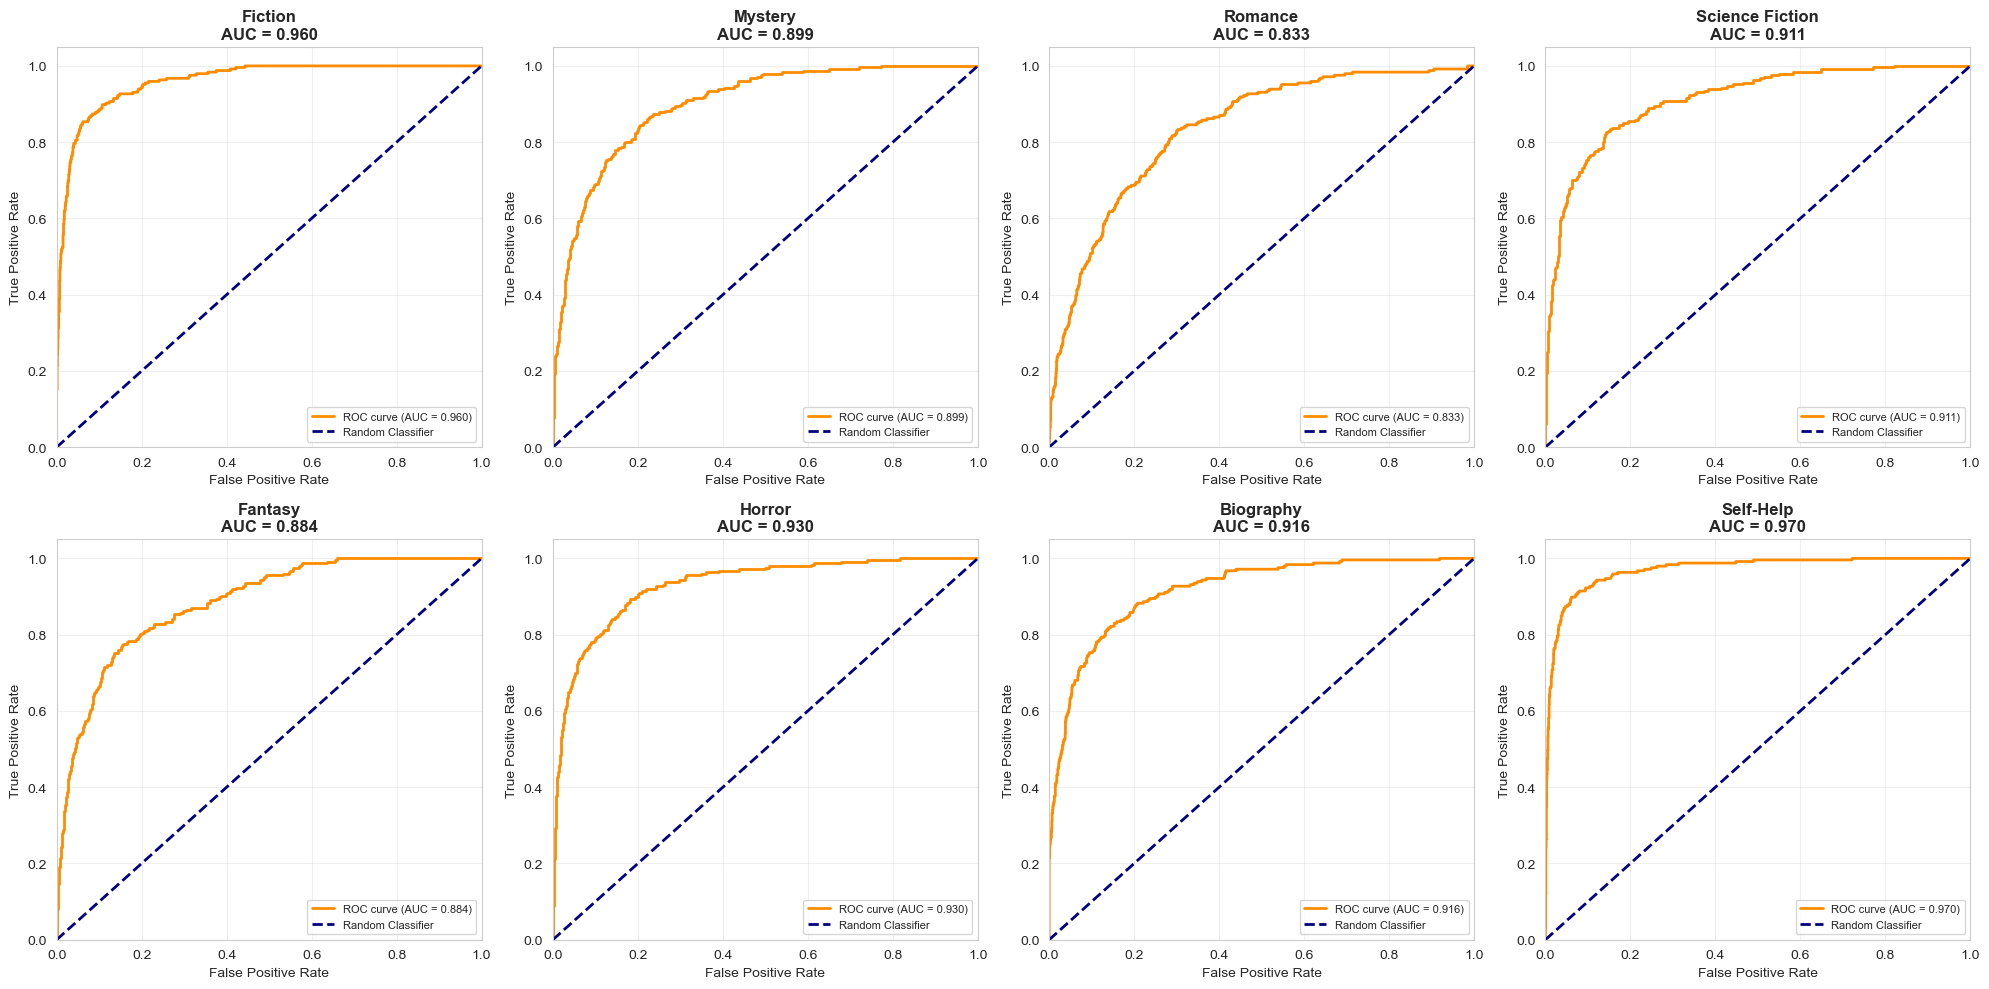


ROC-AUC SCORES BY GENRE
          Genre  AUC Score
      Self-Help   0.970432
        Fiction   0.960025
         Horror   0.929673
      Biography   0.915923
Science Fiction   0.911472
        Mystery   0.899117
        Fantasy   0.883606
        Romance   0.833498

Average AUC: 0.9130


In [91]:
# Binarizing the output for ROC curve calculation
y_test_bin = label_binarize(y_test, classes=range(len(GENRE_NAMES)))

# Calculating ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(GENRE_NAMES)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting ROC curves
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i in range(len(GENRE_NAMES)):
    axes[i].plot(fpr[i], tpr[i], color='darkorange', lw=2, 
                 label=f'ROC curve (AUC = {roc_auc[i]:.3f})')
    axes[i].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_xlabel('False Positive Rate', fontsize=10)
    axes[i].set_ylabel('True Positive Rate', fontsize=10)
    axes[i].set_title(f'{GENRE_NAMES[i]}\nAUC = {roc_auc[i]:.3f}', 
                      fontsize=12, fontweight='bold')
    axes[i].legend(loc="lower right", fontsize=8)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary of AUC scores
print("\n" + "="*80)
print("ROC-AUC SCORES BY GENRE")
print("="*80)
auc_df = pd.DataFrame({
    'Genre': GENRE_NAMES,
    'AUC Score': [roc_auc[i] for i in range(len(GENRE_NAMES))]
}).sort_values('AUC Score', ascending=False)

print(auc_df.to_string(index=False))
print(f"\nAverage AUC: {np.mean([roc_auc[i] for i in range(len(GENRE_NAMES))]):.4f}")

### Precision Recall Curves


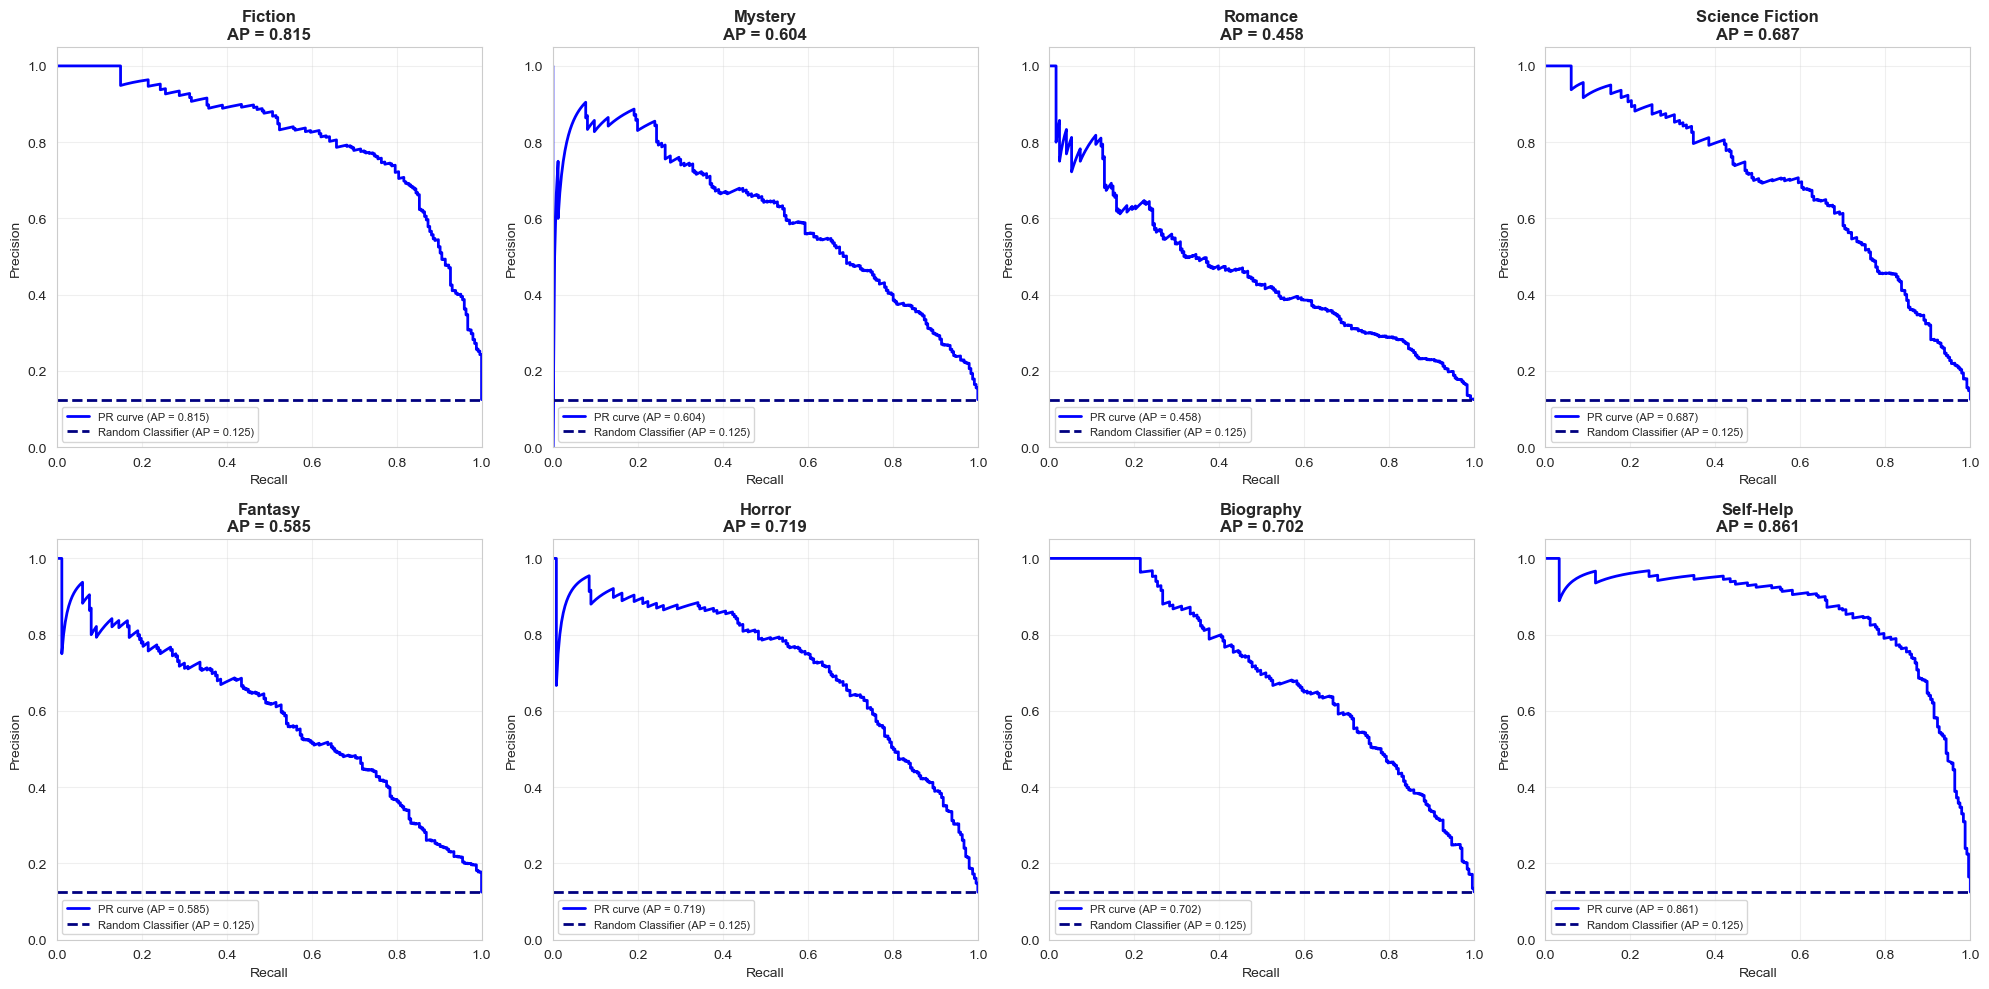


AVERAGE PRECISION SCORES BY GENRE
          Genre  Average Precision
      Self-Help           0.860925
        Fiction           0.814871
         Horror           0.719414
      Biography           0.701783
Science Fiction           0.687432
        Mystery           0.604477
        Fantasy           0.585119
        Romance           0.457787

Mean Average Precision (mAP): 0.6790


In [92]:
# Calculating Precision-Recall curves for each class
precision = dict()
recall = dict()
avg_precision = dict()

for i in range(len(GENRE_NAMES)):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
    avg_precision[i] = average_precision_score(y_test_bin[:, i], y_pred_proba[:, i])

# Plotting Precision-Recall curves
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i in range(len(GENRE_NAMES)):
    axes[i].plot(recall[i], precision[i], color='blue', lw=2, 
                 label=f'PR curve (AP = {avg_precision[i]:.3f})')
    axes[i].axhline(y=1/len(GENRE_NAMES), color='navy', lw=2, linestyle='--', 
                    label=f'Random Classifier (AP = {1/len(GENRE_NAMES):.3f})')
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_xlabel('Recall', fontsize=10)
    axes[i].set_ylabel('Precision', fontsize=10)
    axes[i].set_title(f'{GENRE_NAMES[i]}\nAP = {avg_precision[i]:.3f}', 
                      fontsize=12, fontweight='bold')
    axes[i].legend(loc="lower left", fontsize=8)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary of Average Precision scores
print("\n" + "="*80)
print("AVERAGE PRECISION SCORES BY GENRE")
print("="*80)
ap_df = pd.DataFrame({
    'Genre': GENRE_NAMES,
    'Average Precision': [avg_precision[i] for i in range(len(GENRE_NAMES))]
}).sort_values('Average Precision', ascending=False)

print(ap_df.to_string(index=False))
print(f"\nMean Average Precision (mAP): {np.mean([avg_precision[i] for i in range(len(GENRE_NAMES))]):.4f}")


### Word Cloud for Feature Importance

IMPORTANT WORDS (EXCLUDING COMMON STOP WORDS)
Original vocabulary: 15000 words
After filtering: 14786 words


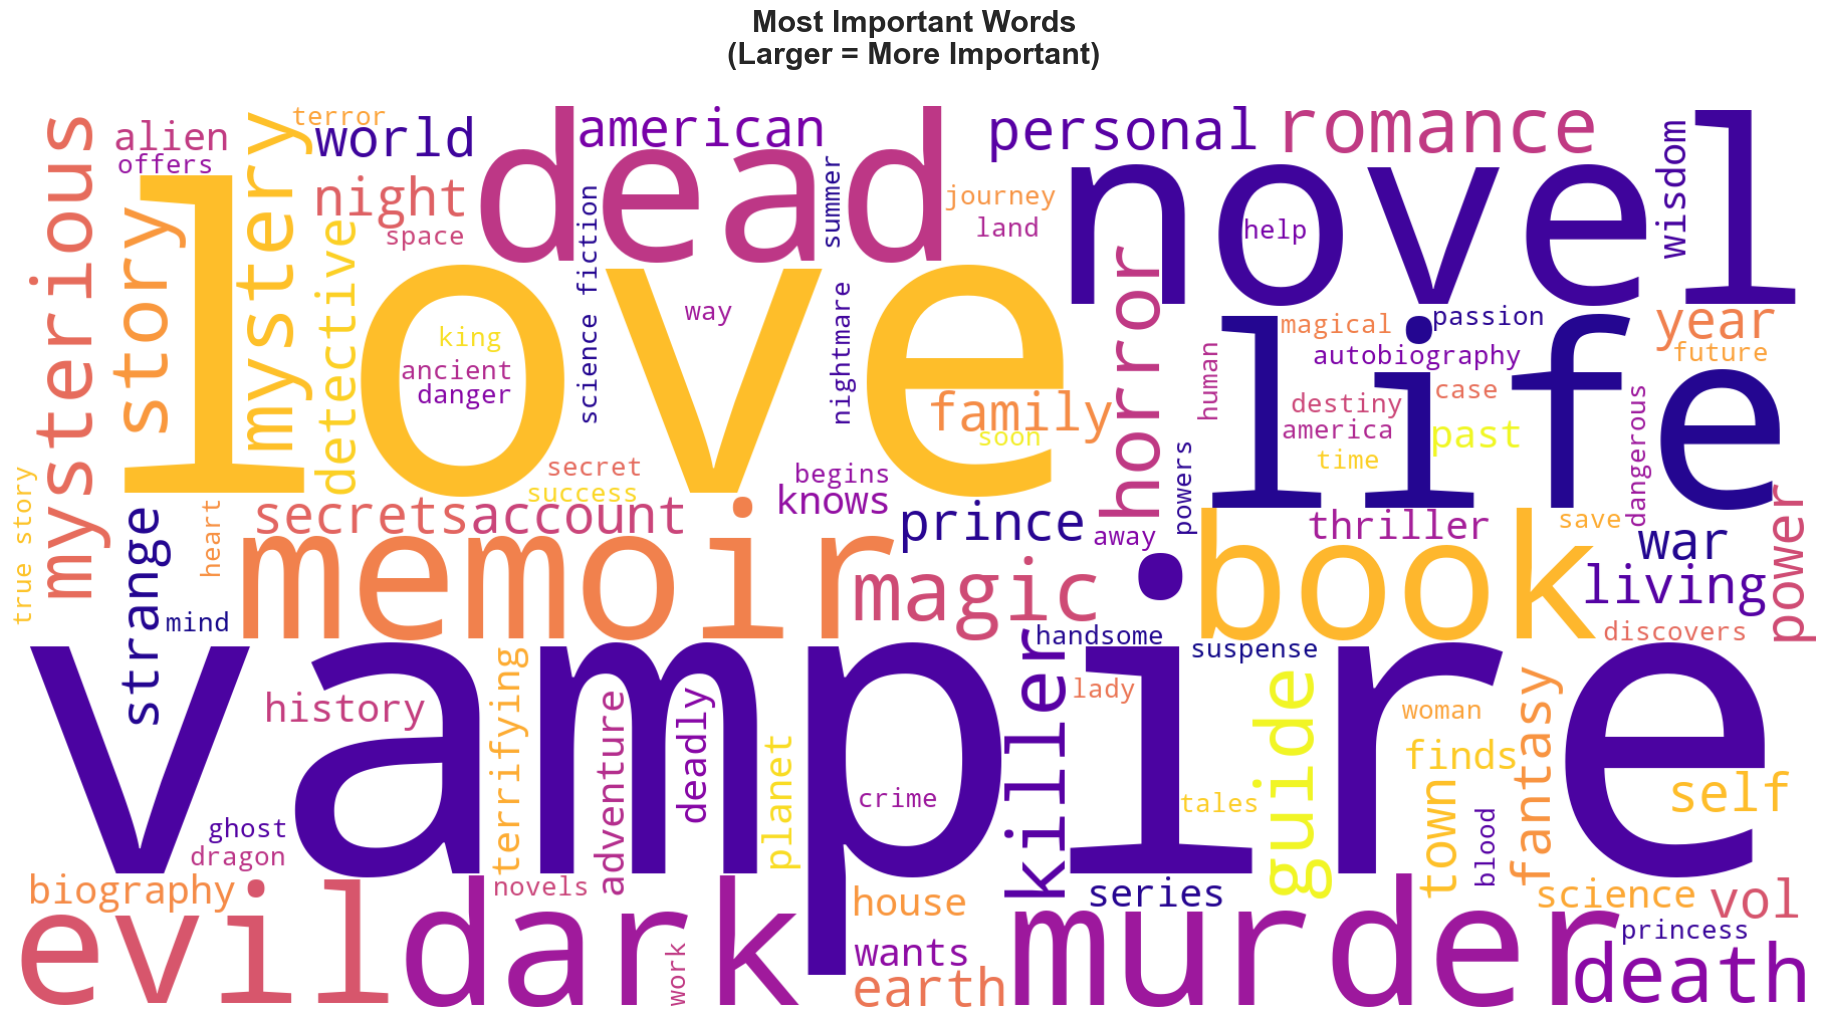


TOP 30 MOST IMPORTANT WORDS
Rank   Word                           Importance Score    
--------------------------------------------------------------------------------
1      vampire                        1.680636
2      love                           1.631067
3      novel                          1.507135
4      life                           1.486202
5      dead                           1.416425
6      memoir                         1.368302
7      murder                         1.359270
8      book                           1.334293
9      dark                           1.318788
10     evil                           1.278453
11     magic                          1.245556
12     mystery                        1.197750
13     mysterious                     1.181401
14     death                          1.142005
15     story                          1.111566
16     horror                         1.101105
17     killer                         1.099889
18     guide                    

In [93]:
print("="*80)
print("IMPORTANT WORDS (EXCLUDING COMMON STOP WORDS)")
print("="*80)



feature_names = vectorizer.get_feature_names_out().tolist()
feature_importance = np.abs(lr_model.coef_).mean(axis=0)

stop_words = {
    'the', 'and', 'of', 'to', 'in', 'is', 'it', 'that', 'for', 'with',
    'as', 'on', 'was', 'at', 'by', 'an', 'be', 'this', 'which', 'or',
    'from', 'but', 'not', 'are', 'his', 'her', 'they', 'have', 'has',
    'had', 'will', 'would', 'can', 'could', 'should', 'may', 'might',
    'you', 'your', 'he', 'she', 'we', 'they', 'them', 'their', 'what',
    'who', 'when', 'where', 'why', 'how', 'all', 'each', 'every', 'some',
    'any', 'many', 'much', 'more', 'most', 'other', 'such', 'no', 'nor',
    'only', 'own', 'same', 'so', 'than', 'too', 'very', 'just', 'about',
    'been', 'being', 'both', 'did', 'do', 'does', 'doing', 'down', 'during',
    'few', 'further', 'here', 'there', 'into', 'off', 'once', 'out', 'over',
    'then', 'through', 'under', 'until', 'up', 'while'
}

# Filtering out stop words
filtered_words = []
filtered_importance = []

for word, importance in zip(feature_names, feature_importance):
    if word.lower() not in stop_words and len(word) > 2:
        filtered_words.append(word)
        filtered_importance.append(importance)

print(f"Original vocabulary: {len(feature_names)} words")
print(f"After filtering: {len(filtered_words)} words")

# Creating dictionary for word cloud
feature_dict = dict(zip(filtered_words, filtered_importance))

# Generating word cloud
wordcloud = WordCloud(
    width=1800, 
    height=900,
    background_color='white',
    colormap='plasma',
    relative_scaling=0.5,
    min_font_size=10,
    max_words=100,
    collocations=False
).generate_from_frequencies(feature_dict)

plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Important Words\n(Larger = More Important)', 
          fontsize=22, fontweight='bold', pad=30)
plt.tight_layout(pad=0)
plt.show()

# Print top 30 filtered words
print("\n" + "="*80)
print("TOP 30 MOST IMPORTANT WORDS")
print("="*80)
print(f"{'Rank':<6} {'Word':<30} {'Importance Score':<20}")
print("-"*80)

sorted_indices = np.argsort(filtered_importance)[::-1]

for i, idx in enumerate(sorted_indices[:30], 1):
    word = filtered_words[idx]
    score = filtered_importance[idx]
    print(f"{i:<6} {word:<30} {score:.6f}")

print("\n" + "="*80)

### Top Words Bar Chart 

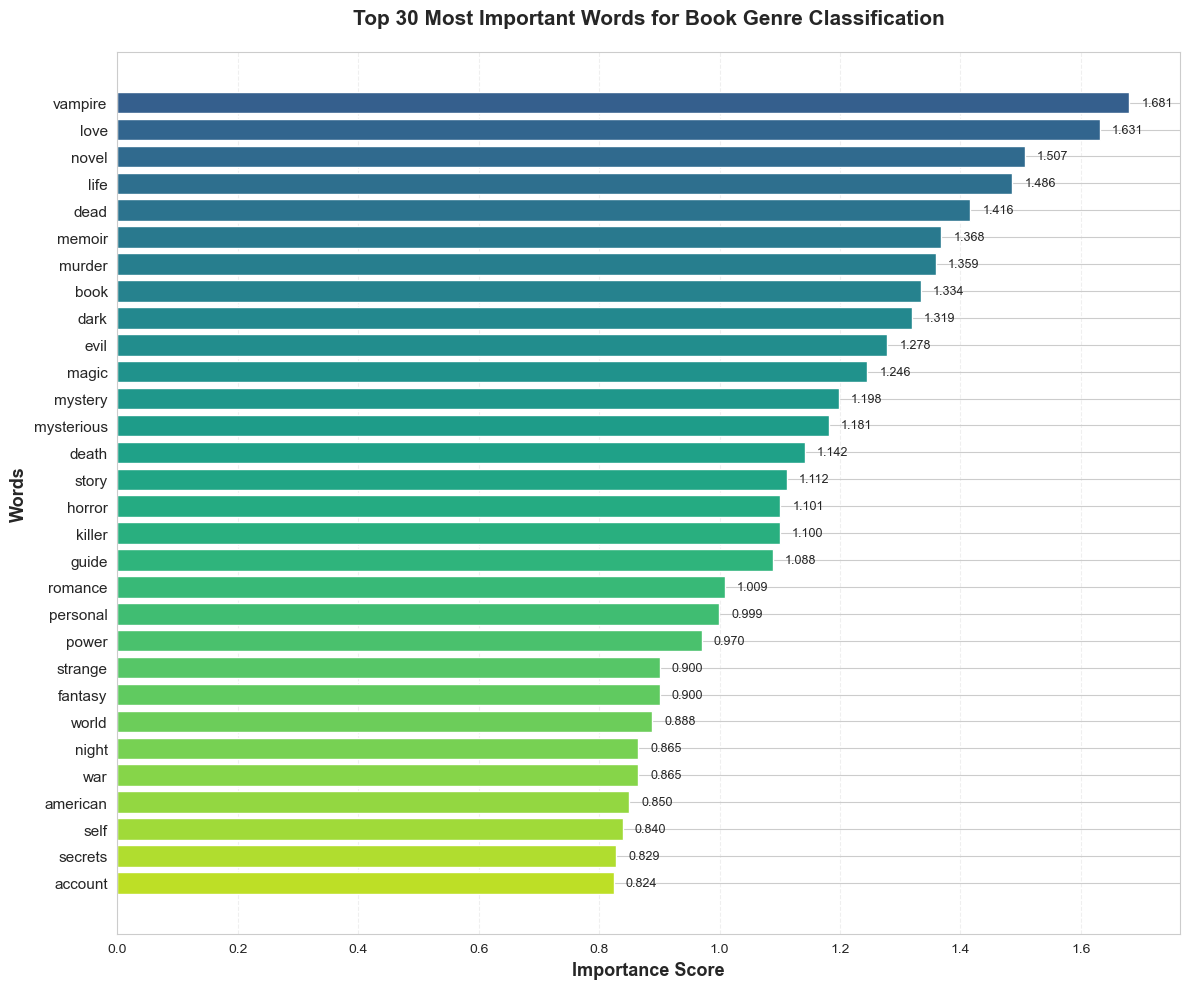

In [94]:
# Sorting and get top 30
sorted_indices = np.argsort(filtered_importance)[::-1][:30]
top_words = [filtered_words[i] for i in sorted_indices]
top_scores = [filtered_importance[i] for i in sorted_indices]

# Creating horizontal bar chart
plt.figure(figsize=(12, 10))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_words)))
bars = plt.barh(range(len(top_words)), top_scores, color=colors)

plt.yticks(range(len(top_words)), top_words, fontsize=11)
plt.xlabel('Importance Score', fontsize=13, fontweight='bold')
plt.ylabel('Words', fontsize=13, fontweight='bold')
plt.title('Top 30 Most Important Words for Book Genre Classification', 
          fontsize=15, fontweight='bold', pad=20)
plt.gca().invert_yaxis()

# Adding value labels on bars
for i, (bar, score) in enumerate(zip(bars, top_scores)):
    plt.text(score + 0.02, bar.get_y() + bar.get_height()/2, 
            f'{score:.3f}', va='center', fontsize=9)

plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

### Genre-Specific Word Cloud


Processing Biography...
Top words for Biography:
  - memoir: 5.4732
  - story: 3.7690
  - account: 3.2969
  - biography: 3.1923
  - novel: 3.1527
  - autobiography: 2.9755
  - true story: 2.6992
  - life: 2.5042
  - years: 2.2673
  - remarkable: 2.1434

Processing Fantasy...
Top words for Fantasy:
  - magic: 3.1560
  - vampire: 3.1070
  - king: 2.3459
  - save: 2.1878
  - witch: 1.9870
  - forever: 1.9763
  - princess: 1.9577
  - wolf: 1.9524
  - dragon: 1.9143
  - destiny: 1.8855

Processing Fiction...
Top words for Fiction:
  - novel: 2.1165
  - poems: 1.6923
  - american: 1.6007
  - dead: 1.5388
  - jesus: 1.5296
  - history: 1.5089
  - magic: 1.4931
  - mysterious: 1.3658
  - death: 1.3181
  - murder: 1.3155

Processing Horror...
Top words for Horror:
  - horror: 4.4044
  - vampire: 3.6156
  - dead: 3.5150
  - evil: 3.3014
  - terrifying: 3.0155
  - dark: 2.9737
  - zombie: 2.5440
  - tales: 2.4647
  - terror: 2.3413
  - blood: 2.2875

Processing Mystery...
Top words for Mystery:


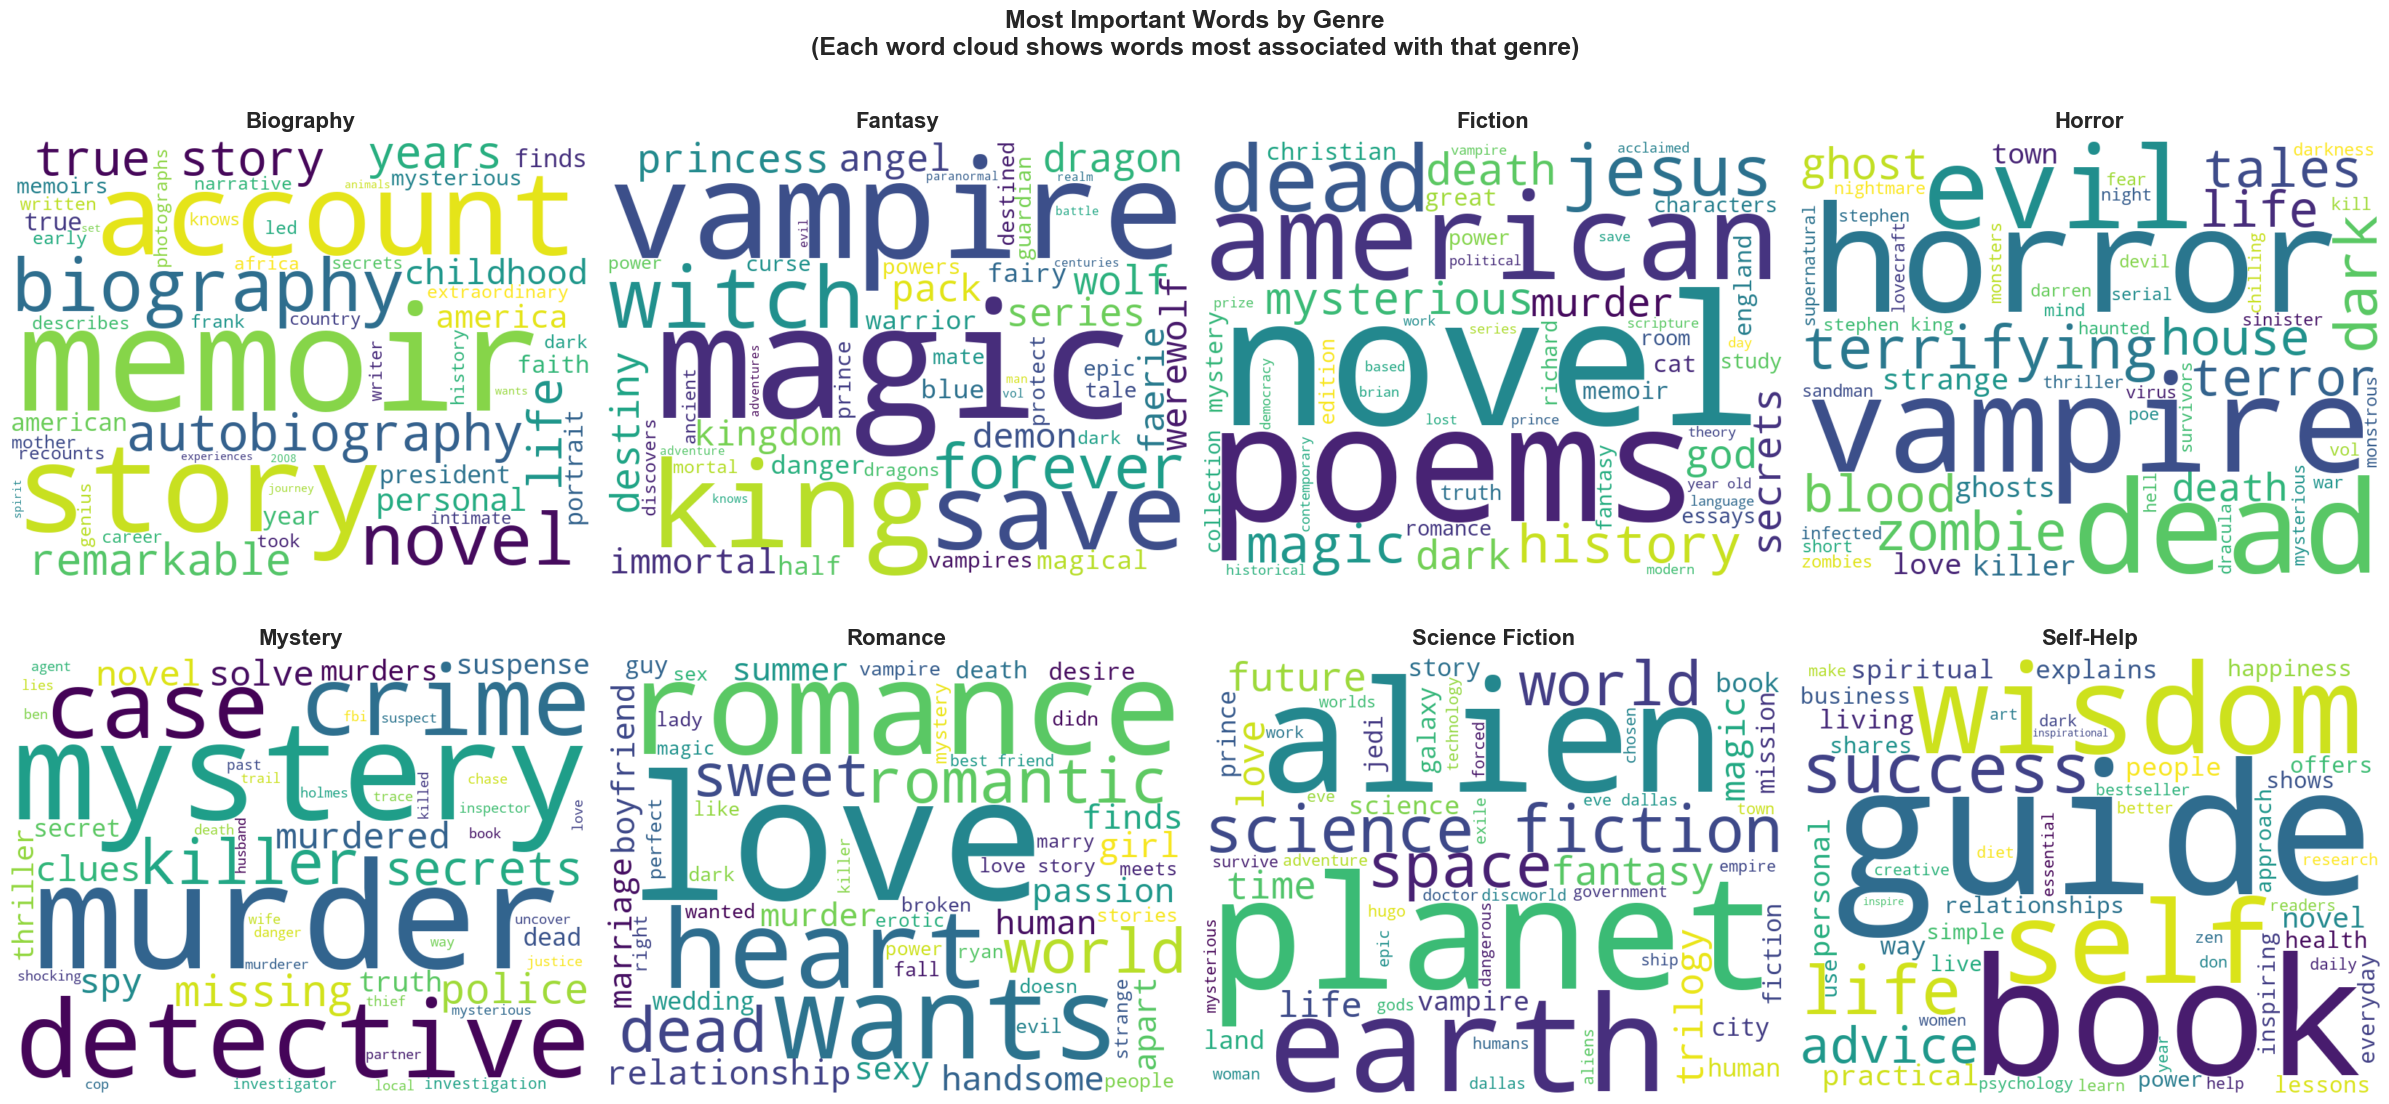


GENRE-SPECIFIC ANALYSIS COMPLETE


In [95]:

# Genre names 
genre_names = ['Biography', 'Fantasy', 'Fiction', 'Horror', 'Mystery', 'Romance', 'Science Fiction', 'Self-Help']

# Getting coefficients for each genre
coefficients = lr_model.coef_


# Creating subplots for all genres
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for i, genre in enumerate(genre_names):
    print(f"\nProcessing {genre}...")
    
    # Getting coefficients for this genre
    genre_coefs = coefficients[i, :]
    
    # Take absolute values for importance
    genre_importance = np.abs(genre_coefs)
    
    # Filter stop words
    filtered_dict = {}
    for word, importance in zip(feature_names, genre_importance):
        if word.lower() not in stop_words and len(word) > 2:
            filtered_dict[word] = importance
    
    # Generate word cloud
    if filtered_dict:
        wordcloud = WordCloud(
            width=800, 
            height=600,
            background_color='white',
            colormap='viridis',
            relative_scaling=0.5,
            min_font_size=8,
            max_words=50,
            collocations=False
        ).generate_from_frequencies(filtered_dict)
        
        axes[i].imshow(wordcloud, interpolation='bilinear')
        axes[i].axis('off')
        axes[i].set_title(f'{genre}', fontsize=16, fontweight='bold', pad=10)
    
    # Print top 10 words for this genre
    sorted_items = sorted(filtered_dict.items(), key=lambda x: x[1], reverse=True)[:10]
    print(f"Top words for {genre}:")
    for word, score in sorted_items:
        print(f"  - {word}: {score:.4f}")

plt.suptitle('Most Important Words by Genre\n(Each word cloud shows words most associated with that genre)', 
             fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("GENRE-SPECIFIC ANALYSIS COMPLETE")
print("="*80)

### Model in Test 

In [101]:
print("\n" + "="*80)
print("LOADING SAVED LOGISTIC REGRESSION MODEL FOR PREDICTION")
print("="*80)

# Loading model + vectorizer
lr_model = joblib.load("../models/lr_genre_model.pkl")
vectorizer = joblib.load("../models/tfidf_vectorizer.pkl")

# Genre names 
genre_names = [
    'Biography', 'Fantasy', 'Fiction', 'Horror', 
    'Mystery', 'Romance', 'Science Fiction', 'Self-Help'
]

print("Model and vectorizer loaded successfully!")

# Asking user for input
book_desc = input("\nEnter a book description to classify:\n\n")
print("="*80)
print("Description provided:")
wrapped = textwrap.fill(book_desc, width=50)
print(wrapped)
print("="*80)


# Transforming input into TF-IDF features
X_input = vectorizer.transform([book_desc])

# Predicting label index
pred_label = lr_model.predict(X_input)[0]

# Getting predicted genre name
pred_genre = genre_names[pred_label]

print("\nPredicted Genre:", pred_genre)
print("="*80)



LOADING SAVED LOGISTIC REGRESSION MODEL FOR PREDICTION
Model and vectorizer loaded successfully!
Description provided:
 comprehensive, practical guide on how to change
your habits and get 1% better every day. Using a
framework called the Four Laws of Behavior Change,
Atomic Habits teaches readers a simple set of
rules for creating good habits and breaking bad
ones. Read the full summary to glean 3 key lessons
from Atomic Habits, learn how to build a habit in
4 simple steps, and get a handy reference guide
for the strategies recommended throughout the
book.

Predicted Genre: Self-Help
